## 2. Ablation Studies
As part of this, I will try removing a key component of my methodology - the class-weighting, to analyse the impact on my model. Most of this code is copied over from `BestModel/stage4.ipynb` as the rest of the training procedure remains identical.

The key change here is that `pos_class_weight = 1` instead of `sqrt(num_neg / num_pos)`.

In [5]:
!pip install -r ../requirements.txt

In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import torch
import torch.nn as nn

ModuleNotFoundError: Could not import module 'AutoTokenizer'. Are this object's requirements defined correctly?

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import set_seed

SEED = 42
set_seed(SEED)

MODEL = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=1
)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 849.36it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

**NOTE**: This filtered data CSV contains the binarised version of the original dataset WITH label 2 dropped. This was done during the EDA process. Please refer to `eda/eda.ipynb` for this code.


In [ ]:
DATA_FOLDER_PATH = "../data" 
DATASET_PATH = f"{DATA_FOLDER_PATH}/filtered_pcl_task_data.csv"

data = pd.read_csv(DATASET_PATH)
data.head()

# Assert that this data has been binarised into {0,1} label format
assert((data["label"].unique() == np.ndarray([0,1])).all())

# We have a Null value, hence we drop it 
null_values = data[["text", "label"]].isnull().sum() > 0
print(null_values)
if null_values.any():
    data = data.dropna(subset=["text", "label"]).reset_index(drop=True)

text      True
label    False
dtype: bool


In [ ]:
train_data = pd.read_csv(f"{DATA_FOLDER_PATH}/train_data.csv")
val_data = pd.read_csv(f"{DATA_FOLDER_PATH}/val_data.csv")

In [ ]:
# Determine class imbalance and weights to apply
train_labels = train_data["label"].values
n_neg = np.sum(train_labels == 0)
n_pos = np.sum(train_labels == 1)

print(f"Non-PCL: {n_neg}, PCL: {n_pos}, Ratio: {n_neg/n_pos:.2f}")

# Square root weighting to avoid being too aggressive
pos_class_weight = torch.tensor(1, dtype=torch.float)
print(f"Class weights: {pos_class_weight}")

Non-PCL: 7581, PCL: 668, Ratio: 11.35
Class weights: 1.0


In [ ]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
    )

# Pads inputs to the longest sequence in batch. Required to ensure consistent batch sizes
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")

train_dataset = Dataset.from_pandas(train_data)
val_dataset = Dataset.from_pandas(val_data)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")

# Convert columns to torch tensors
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 2075/2075 [00:00<00:00, 13914.78 examples/s]


In [ ]:
# Define custom trainer to perform class-weighted BCE 

from transformers import Trainer

class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float().view(-1)
        outputs = model(**inputs)
        logits = outputs.logits.view(-1)

        pos_weight = pos_class_weight.to(logits.device).view(())  # scalar
        loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [ ]:
from transformers import get_cosine_schedule_with_warmup

def get_optimizer_params(model, base_lr, weight_decay=0.01, layerwise_lr_decay=0.9):
    no_decay = ["bias", "LayerNorm.bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = []
    
    # helper to split params into decay/no-decay
    def get_layer_params(params, lr):
        return [
            {"params": [p for n, p in params if not any(nd in n for nd in no_decay)], 
             "weight_decay": weight_decay, "lr": lr},
            {"params": [p for n, p in params if any(nd in n for nd in no_decay)], 
             "weight_decay": 0.0, "lr": lr}
        ]

    # 1. Head (Classifier & Pooler)
    head_params = [(n, p) for n, p in model.named_parameters() if "classifier" in n or "pooler" in n]
    optimizer_grouped_parameters.extend(get_layer_params(head_params, base_lr))

    # 2. Encoder Layers (11 down to 0)
    current_lr = base_lr
    for i in range(11, -1, -1):
        current_lr *= layerwise_lr_decay
        layer_params = [(n, p) for n, p in model.named_parameters() if f"encoder.layer.{i}." in n]
        optimizer_grouped_parameters.extend(get_layer_params(layer_params, current_lr))

    # 3. Embeddings
    current_lr *= layerwise_lr_decay
    emb_params = [(n, p) for n, p in model.named_parameters() if "embeddings" in n]
    optimizer_grouped_parameters.extend(get_layer_params(emb_params, current_lr))

    return optimizer_grouped_parameters

In [ ]:
from torch.optim import AdamW

TRAIN_BATCH_SIZE = 16
NUM_EPOCHS = 20

# Setup the grouped parameters
grouped_params = get_optimizer_params(model, base_lr=2e-5)

# Create the Optimizer
optimizer = AdamW(grouped_params, lr=2e-5, eps=1e-6)

# Calculate real steps for the scheduler
steps_per_epoch = len(train_dataset) // TRAIN_BATCH_SIZE
total_steps = steps_per_epoch * NUM_EPOCHS

scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=int(total_steps * 0.1), 
    num_training_steps=total_steps
)

In [ ]:
'''
Define function to compute F1 score from the objects of type EvalPrediction. The key members of the class we care about are:
    - predictions (np.ndarray) — Predictions of the model.
    - label_ids (np.ndarray) — Targets to be matched.
'''

from sklearn.metrics import f1_score

def compute_f1_score(eval_pred):
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    logits = np.asarray(logits).reshape(-1)
    labels = np.asarray(labels).reshape(-1).astype(int)

    probs = 1 / (1 + np.exp(-logits))

    preds = (probs >= 0.5).astype(int)
    f1 = f1_score(labels, preds)

    return {"f1": f1, "best_threshold": 0.5}

    # search thresholds
    # thresholds = np.arange(0.1, 0.9 + 1e-8, 0.05)
    # best_f1, best_t = -1.0, 0.5
    # for t in thresholds:
    #     preds = (probs >= t).astype(int)
    #     f1 = f1_score(labels, preds)
    #     if f1 > best_f1:
    #         best_f1, best_t = f1, t

    # return {"f1": best_f1, "best_threshold": best_t}

In [ ]:
# Writing a training callback to save the threshold which results in best F1 score in the model's config 
from transformers import TrainerCallback

class StoreBestThresholdCallback(TrainerCallback):
    """
    Watches eval metrics, and whenever eval_f1 improves, stores the corresponding
    eval_best_threshold into model.config (and also best_f1).
    """
    def __init__(self):
        self.best_f1 = float("-inf")
        self.best_t = 0.5

    def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
        if metrics is None or model is None:
            return

        f1 = metrics.get("eval_f1")
        t  = metrics.get("eval_best_threshold")
        if f1 is None or t is None:
            return

        f1 = float(f1)
        t  = float(t)

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.best_t = t

            # Store in config so it gets saved with save_model/save_pretrained
            model.config.best_threshold = t
            model.config.best_f1 = f1

In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="../checkpoints", # Store checkpoints in this directory
    seed=SEED,
    data_seed=SEED,
    num_train_epochs=20,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    metric_for_best_model="f1", # Evaluate performance using F1 score on validation set
    greater_is_better=True, # Higher F1 score on val set is better
    load_best_model_at_end=True,
    fp16=False,
    bf16=False,
    max_grad_norm=1.0,
)

In [ ]:
trainer = WeightedBCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,    # Dynamically pads received inputs
    compute_metrics=compute_f1_score,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2), # Early stopping based on metric provided by `metric_for_best_model`
        StoreBestThresholdCallback()
    ],   
    optimizers=(optimizer, scheduler)
)

trainer.train(resume_from_checkpoint=True)

Epoch,Training Loss,Validation Loss


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 11.81 MiB is free. Process 2390 has 12.22 GiB memory in use. Including non-PyTorch memory, this process has 2.33 GiB memory in use. Of the allocated memory 2.01 GiB is allocated by PyTorch, and 191.28 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Saving the best model
trainer.save_model("best_model")
tokenizer.save_pretrained("best_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.79it/s]


('best_model/tokenizer_config.json', 'best_model/tokenizer.json')

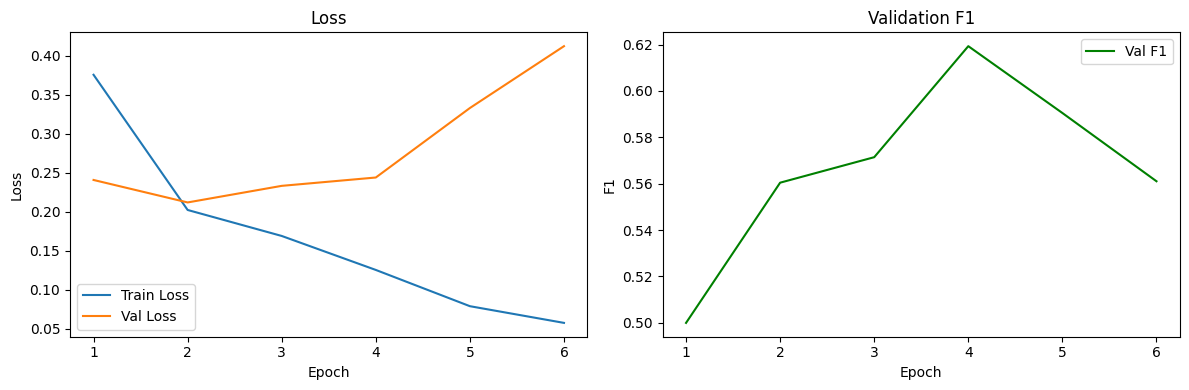

In [ ]:
# Plot results after completion of training

log_history = trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

train_loss = [x["loss"] for x in train_logs]
eval_loss  = [x["eval_loss"] for x in eval_logs]
eval_f1    = [x["eval_f1"] for x in eval_logs]
epochs     = [x["epoch"] for x in eval_logs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, label="Train Loss")
ax1.plot(epochs, eval_loss, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.set_title("Loss")

ax2.plot(epochs, eval_f1, label="Val F1", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1")
ax2.legend()
ax2.set_title("Validation F1")

plt.tight_layout()
plt.show()
